In [1]:
import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


# Load the image arrays from the jpgs
exp_img = cv2.imread('/home/thiago/Desktop/Argonne/ingrained_test/Images_for_ssim/denoised_13_crop.png')
incostem_img = cv2.imread('/home/thiago/Desktop/Argonne/ingrained_test/Images_for_ssim/Incostem_img.png')
dr_probe_img = cv2.imread('/home/thiago/Desktop/Argonne/ingrained_test/Images_for_ssim/250x250x30_Stem_crop.png')

# Check if they are the same size
print(exp_img.shape)
print(incostem_img.shape)
print(dr_probe_img.shape)




(230, 330, 3)
(480, 640, 3)
(416, 429, 3)


In [24]:
# Crop the incostem_img and dr_probe_img to make them the same size as the experimental image
x_i, x_j = 20, 408  # Define your cropping coordinates for incostem_img
y_i, y_j = 20, 406
dr_probe_img = dr_probe_img[x_i:x_j, y_i:y_j]

print(dr_probe_img.shape)

x_n, x_m = 50, 420  # Define your cropping coordinates for dr_probe_img
y_n, y_m = 10, 420
incostem_img = incostem_img[x_n:x_m, y_n:y_m]


print(incostem_img.shape)

(388, 386, 3)
(370, 410, 3)


In [25]:
# Assuming these are the dimensions you want to use for resizing


exp_img_nx = exp_img.shape[0]
incostem_n_x = incostem_img.shape[0]

exp_img_ny = exp_img.shape[1]
incostem_n_y = incostem_img.shape[1]


new_x_I = int(exp_img_nx)
new_y_I = int(exp_img_ny)


# Resize the incostem_img
incostem_img = cv2.resize(incostem_img, (new_y_I,new_x_I))


# Check if they are the same size
#print(exp_img.shape)
print(incostem_img.shape)

(230, 330, 3)


In [26]:
exp_img_nx = exp_img.shape[0]
dr_probe_n_x = dr_probe_img.shape[0]

exp_img_ny = exp_img.shape[1]
dr_probe_n_y = dr_probe_img.shape[1]

new_x_P = int(dr_probe_n_x * (exp_img_nx / dr_probe_n_x))
new_y_P = int(dr_probe_n_y * (exp_img_ny / dr_probe_n_y))

# Resize the incostem_img
dr_probe_img = cv2.resize(dr_probe_img, (new_y_P, new_x_P))

# Check if they are the same size
print(exp_img.shape)
print(incostem_img.shape)
print(dr_probe_img.shape)

(230, 330, 3)
(230, 330, 3)
(230, 330, 3)


In [37]:
def score_ssim(img1, img2):
    """
    Compute the mean structural similarity index between two images

    Args:
        img1, img2: (ndarray) images

    Return:
        1 - the mean structural similarity index (i.e. ΔSSIM)
    """
    img1 = scale_pixels(img1, mode="rescale")
    img2 = scale_pixels(img2, mode="rescale")
    data_range = 255  # Dynamic range of pixel values in typical images
    return ssim(img1, img2, data_range=255, full=True, win_size=1, use_sample_covariance=False)


In [28]:
def scale_pixels(img, mode=None):
    """
    Select a pixel scaling technique

    Args:
        mode: (string) pixel scaling technique
          rescale    :  stretch the pixel intensities so to fill the 
                        range from 0 to 1 (float64)
          center     :  enforce zero mean, unit variance (float64)
          grayscale  :  stretch the pixel intensities so to fill the 
                        range from 0 to 255 (uint8)

    Returns:
        A numpy array (either float64 or uint8) of the scaled image.
    """
    img = img.astype(np.float64)
    if mode == None:
        return img
    elif mode == "rescale":
        return ((img - img.min()) / (img.max() - img.min()) + 1e-16).astype(np.float64)
    elif mode == "center":
        return ((img - img.mean()) / (img.std())).astype(np.float64)
    elif mode == "grayscale":
        return (255 * (img - img.min()) / (img.max() - img.min()) + 1e-16).astype(
            np.uint8
        )

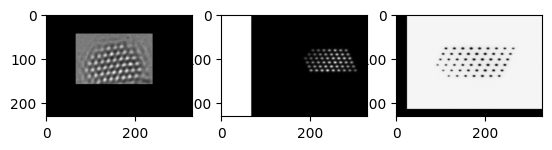

In [31]:
# Get the ssim scores
incostem_score = score_ssim(exp_img, incostem_img)
dr_probe_score = score_ssim(exp_img, dr_probe_img)

# Plot the images
f, axes = plt.subplots(1, 3)
axes[0].imshow(exp_img, cmap='gray')
axes[1].imshow(incostem_img, cmap='gray')
axes[2].imshow(dr_probe_img, cmap='gray')
plt.show()


In [39]:
score_ssim(exp_img, dr_probe_img)[0]

0.9148326019712517